Exploratory Data Analysis – School Dataset
Day 1 Task | Data Science

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('Libraries loaded')


Libraries loaded


1. Data Understanding

In [7]:
df = pd.read_excel('School data.xlsx')
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset Shape: 5200 rows × 17 columns


In [9]:
df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [11]:
print('Column Info')
df.info()

Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          4940 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             4940 non-null   float64
 12  Functional_Toilets             5200 

In [102]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
%_Math_Score,4942.0,60.055898,15.106160,0.326857,49.5825,59.85,70.6300,107.344878
%_Language_Score,5200.0,62.970896,16.569802,1.380000,51.5200,63.03,74.4525,100.000000
%_Science_Score,5200.0,61.338762,18.025438,1.510000,48.8900,61.15,73.9500,100.000000
Teacher_Student_Ratio,4940.0,29.980951,9.957824,1.000000,23.1000,29.80,36.6000,100.000000
Avg_Teacher_Experience_Years,5200.0,8.096596,3.916906,0.000000,5.4000,8.00,10.8000,22.700000
Teacher_Trainings_Attended,5200.0,1.995385,1.430434,0.000000,1.0000,2.00,3.0000,9.000000
Electricity_Available,5200.0,0.895577,0.305838,0.000000,1.0000,1.00,1.0000,1.000000
Internet_Available,4940.0,0.295344,0.456243,0.000000,0.0000,0.00,1.0000,1.000000
Functional_Toilets,5200.0,0.954423,0.208586,0.000000,1.0000,1.00,1.0000,1.000000
Library_Available,5200.0,0.483462,0.499774,0.000000,0.0000,0.00,1.0000,1.000000


In [104]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

Categorical columns: ['School_ID', 'District', 'Block', 'Urban_Rural']

--- School_ID ---
School_ID
SCH_1       1
SCH_3455    1
SCH_3473    1
SCH_3472    1
SCH_3471    1
           ..
SCH_1732    1
SCH_1731    1
SCH_1730    1
SCH_1729    1
SCH_5200    1
Name: count, Length: 5200, dtype: int64

--- District ---
District
District_C    1810
District_A    1699
District_B    1691
Name: count, dtype: int64

--- Block ---
Block
Block_C3    622
Block_C2    595
Block_A2    594
Block_C1    593
Block_B2    590
Block_B3    574
Block_A1    557
Block_A3    548
Block_B1    527
Name: count, dtype: int64

--- Urban_Rural ---
Urban_Rural
Rural    3579
Urban    1621
Name: count, dtype: int64


2. Data Cleaning

In [107]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
%_Math_Score,258,4.96
Teacher_Student_Ratio,260,5.00
Internet_Available,260,5.00
Parent_Literacy_Rate,259,4.98


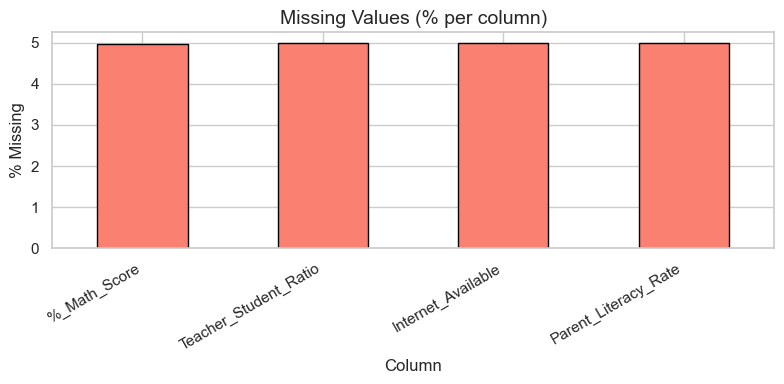

In [109]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Missing Values (% per column)')
ax.set_ylabel('% Missing')
ax.set_xlabel('Column')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [111]:
cols_with_missing = ['%_Math_Score', 'Teacher_Student_Ratio', 'Internet_Available', 'Parent_Literacy_Rate']

for col in cols_with_missing:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'{col}: filled with median = {median_val:.2f}')

print('\nMissing values after imputation:')
print(df.isnull().sum().sum(), 'missing values remaining')

%_Math_Score: filled with median = 59.85
Teacher_Student_Ratio: filled with median = 29.80
Internet_Available: filled with median = 0.00
Parent_Literacy_Rate: filled with median = 49.50

Missing values after imputation:
0 missing values remaining


In [117]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates — dataset is clean')

Duplicate rows found: 0
No duplicates — dataset is clean


In [119]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print('Outlier counts per column (IQR method):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} outliers')

Outlier counts per column (IQR method):
  %_Math_Score: 53 outliers
  %_Language_Score: 12 outliers
  %_Science_Score: 8 outliers
  Teacher_Student_Ratio: 32 outliers
  Avg_Teacher_Experience_Years: 12 outliers
  Teacher_Trainings_Attended: 32 outliers
  Electricity_Available: 543 outliers
  Functional_Toilets: 237 outliers
  %_Marginalized_Students: 4 outliers
  %_Students_With_Home_Internet: 17 outliers
  Parent_Literacy_Rate: 53 outliers


3. EDA – Exploratory Data Analysis

3.1 Univariate Analysis – Score Distributions

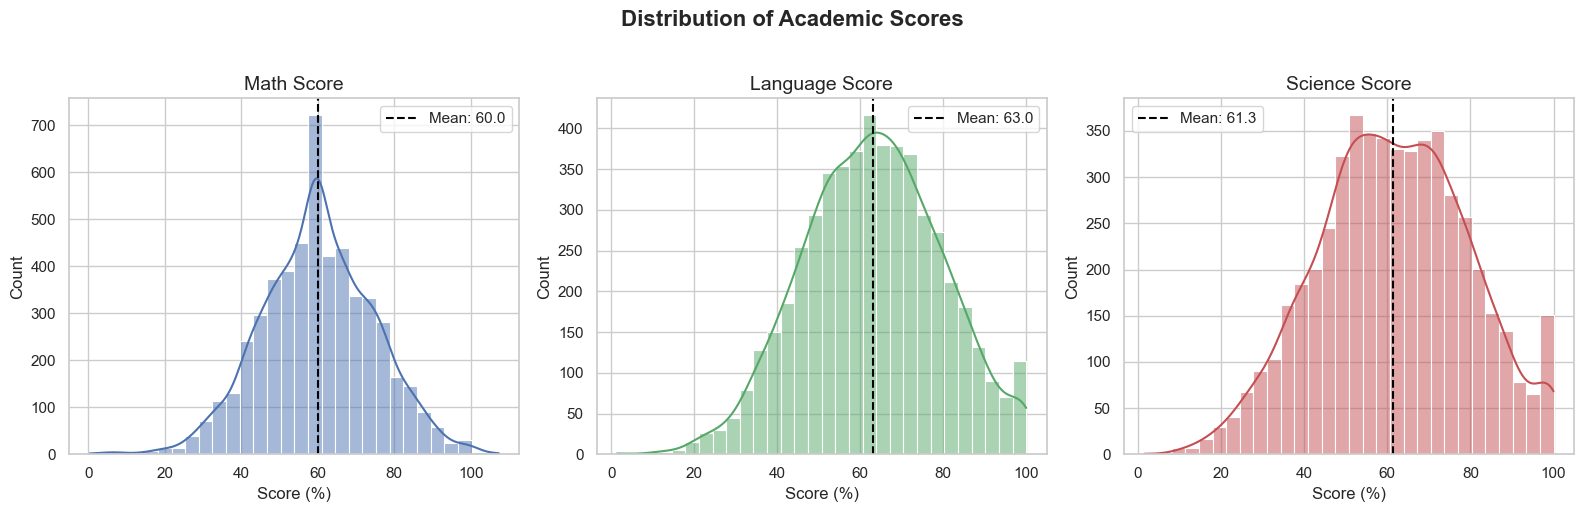

In [123]:
score_cols = ['%_Math_Score', '%_Language_Score', '%_Science_Score']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, col, color in zip(axes, score_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=30)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(col.replace('%_', '').replace('_Score', ' Score'))
    ax.set_xlabel('Score (%)')
    ax.legend()

plt.suptitle('Distribution of Academic Scores', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

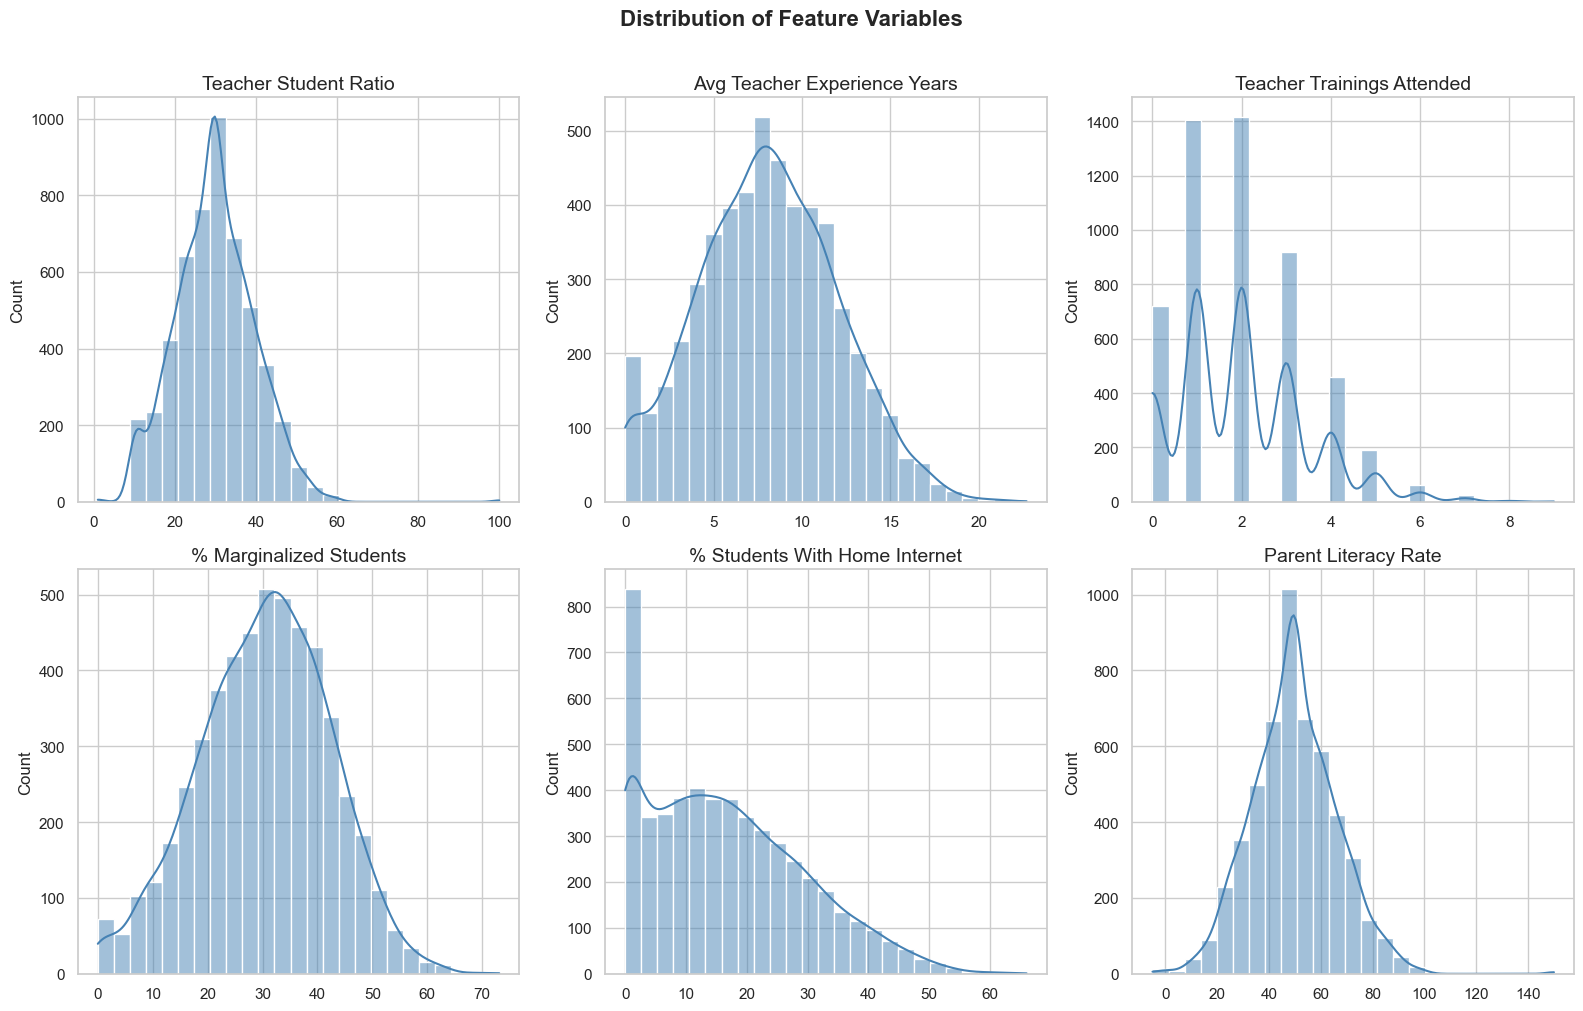

In [125]:
other_num = ['Teacher_Student_Ratio', 'Avg_Teacher_Experience_Years',
             'Teacher_Trainings_Attended', '%_Marginalized_Students',
             '%_Students_With_Home_Internet', 'Parent_Literacy_Rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, other_num):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=25)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')

plt.suptitle('Distribution of Feature Variables', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

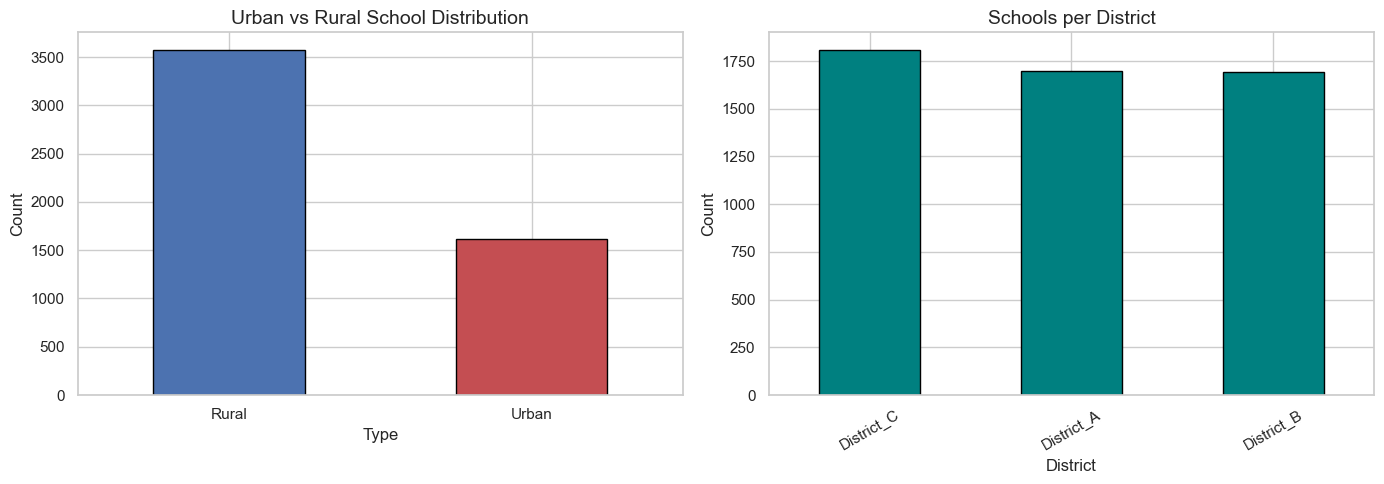

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Urban_Rural'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#C44E52'], edgecolor='black')
axes[0].set_title('Urban vs Rural School Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['District'].value_counts().plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Schools per District')
axes[1].set_xlabel('District')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

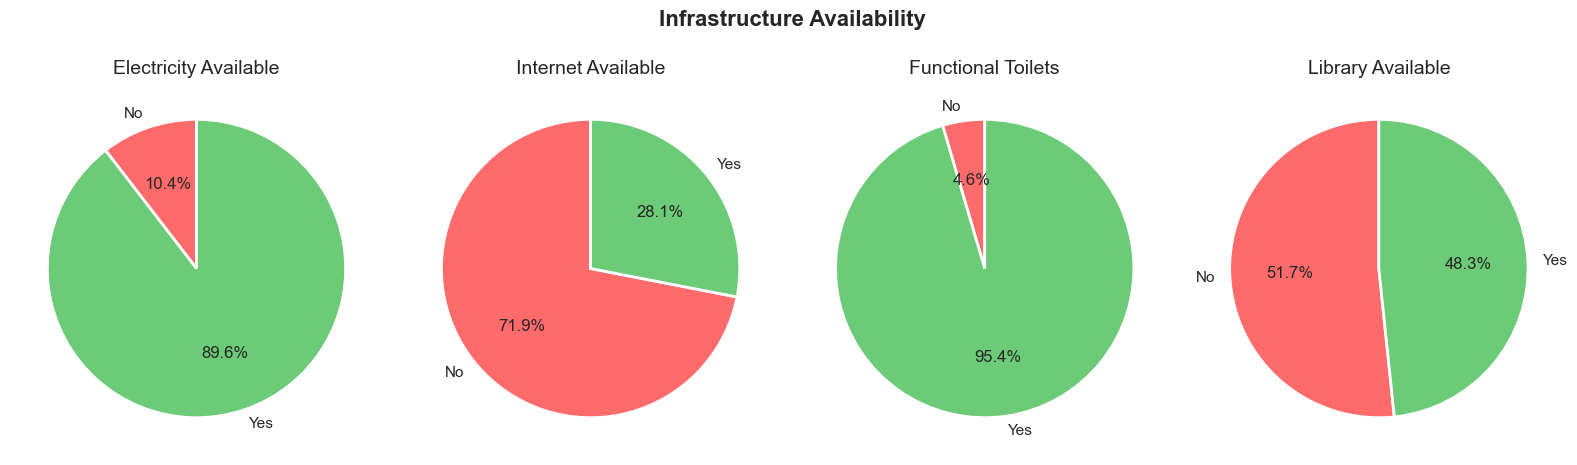

In [129]:
infra_cols = ['Electricity_Available', 'Internet_Available', 'Functional_Toilets', 'Library_Available']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
labels = ['No', 'Yes']

for ax, col in zip(axes, infra_cols):
    counts = df[col].value_counts().sort_index()
    ax.pie(counts, labels=labels[:len(counts)], autopct='%1.1f%%',
           colors=['#FF6B6B', '#6BCB77'], startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(col.replace('_', ' '))

plt.suptitle('Infrastructure Availability', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

3.2 Bivariate Analysis

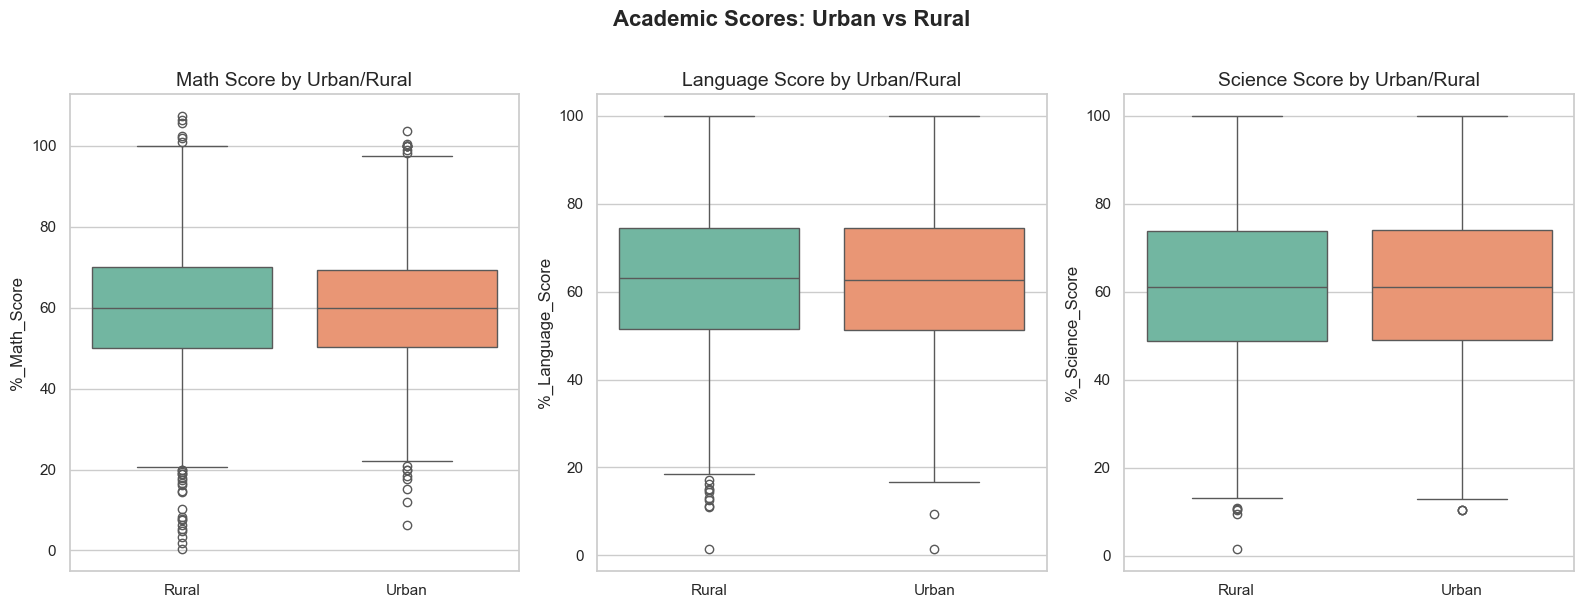

In [132]:
# Scores by Urban vs Rural
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axes, score_cols):
    sns.boxplot(data=df, x='Urban_Rural', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col.replace("%_","").replace("_Score"," Score")} by Urban/Rural')
    ax.set_xlabel('')

plt.suptitle('Academic Scores: Urban vs Rural', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

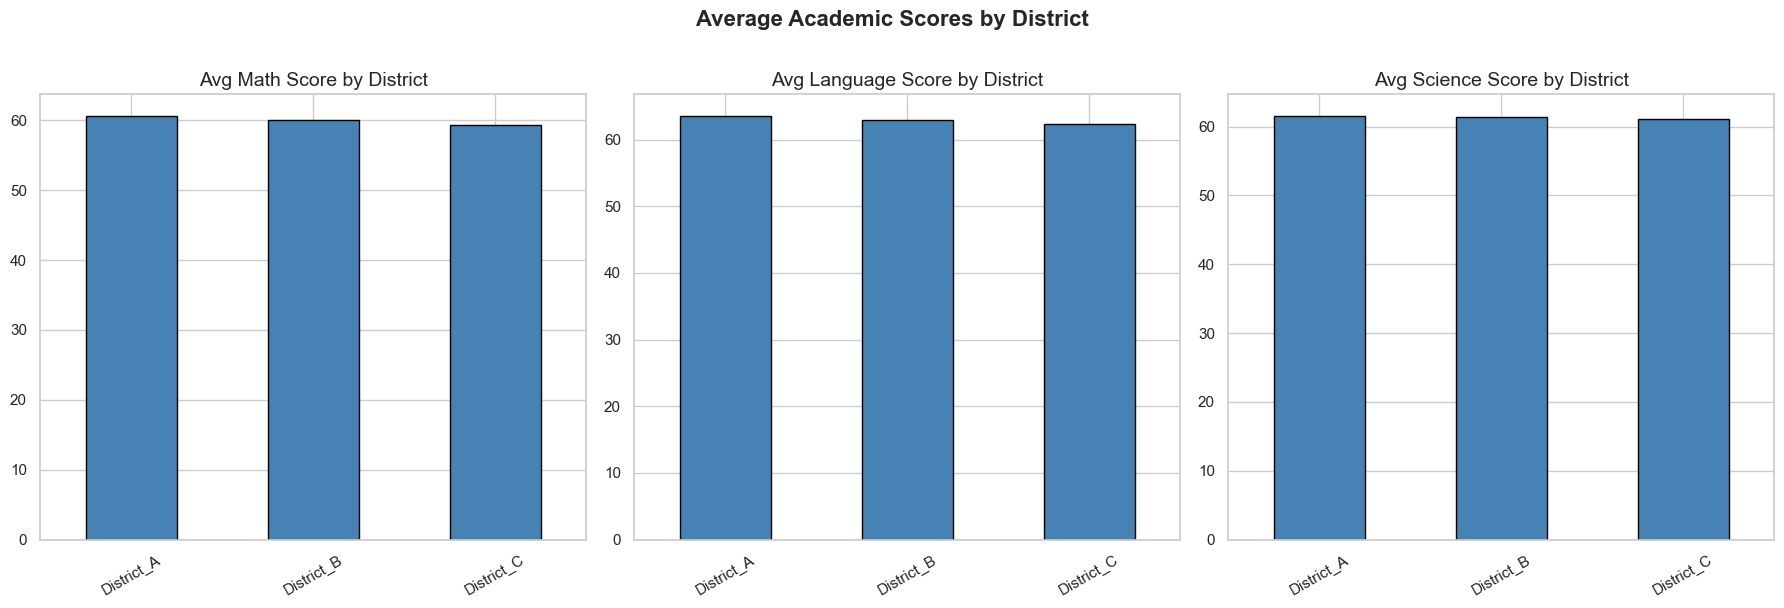

In [134]:
# Scores by District
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, score_cols):
    district_means = df.groupby('District')[col].mean().sort_values(ascending=False)
    district_means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Avg {col.replace("%_","").replace("_Score"," Score")} by District')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Average Academic Scores by District', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

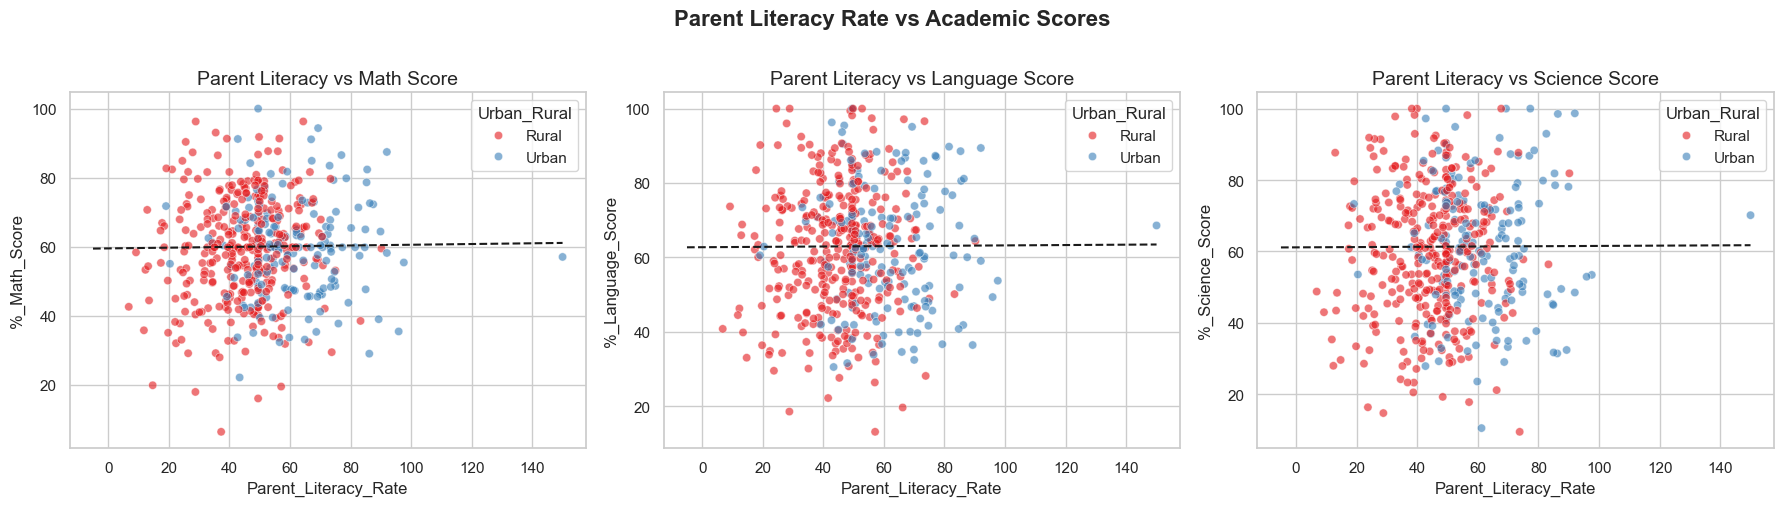

In [136]:
# Parent Literacy Rate vs Math Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, score_cols):
    sns.scatterplot(data=df.sample(500, random_state=42),
                    x='Parent_Literacy_Rate', y=col, ax=ax,
                    hue='Urban_Rural', alpha=0.6, palette='Set1')
    # Regression line
    m, b = np.polyfit(df['Parent_Literacy_Rate'], df[col], 1)
    x_line = np.linspace(df['Parent_Literacy_Rate'].min(), df['Parent_Literacy_Rate'].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k--', linewidth=1.5)
    ax.set_title(f'Parent Literacy vs {col.replace("%_","").replace("_Score"," Score")}')

plt.suptitle('Parent Literacy Rate vs Academic Scores', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

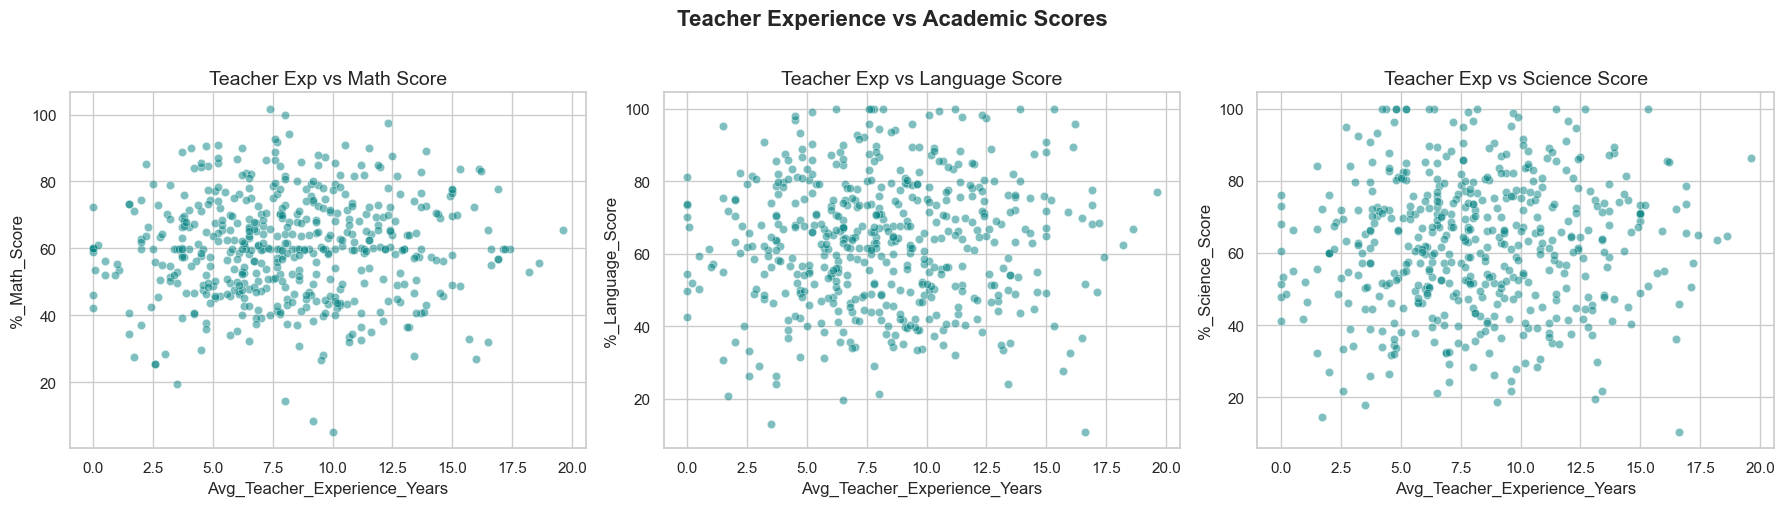

In [137]:
# Teacher Experience vs Scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, score_cols):
    sns.scatterplot(data=df.sample(500, random_state=1),
                    x='Avg_Teacher_Experience_Years', y=col,
                    ax=ax, alpha=0.5, color='teal')
    ax.set_title(f'Teacher Exp vs {col.replace("%_","").replace("_Score"," Score")}')

plt.suptitle('Teacher Experience vs Academic Scores', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

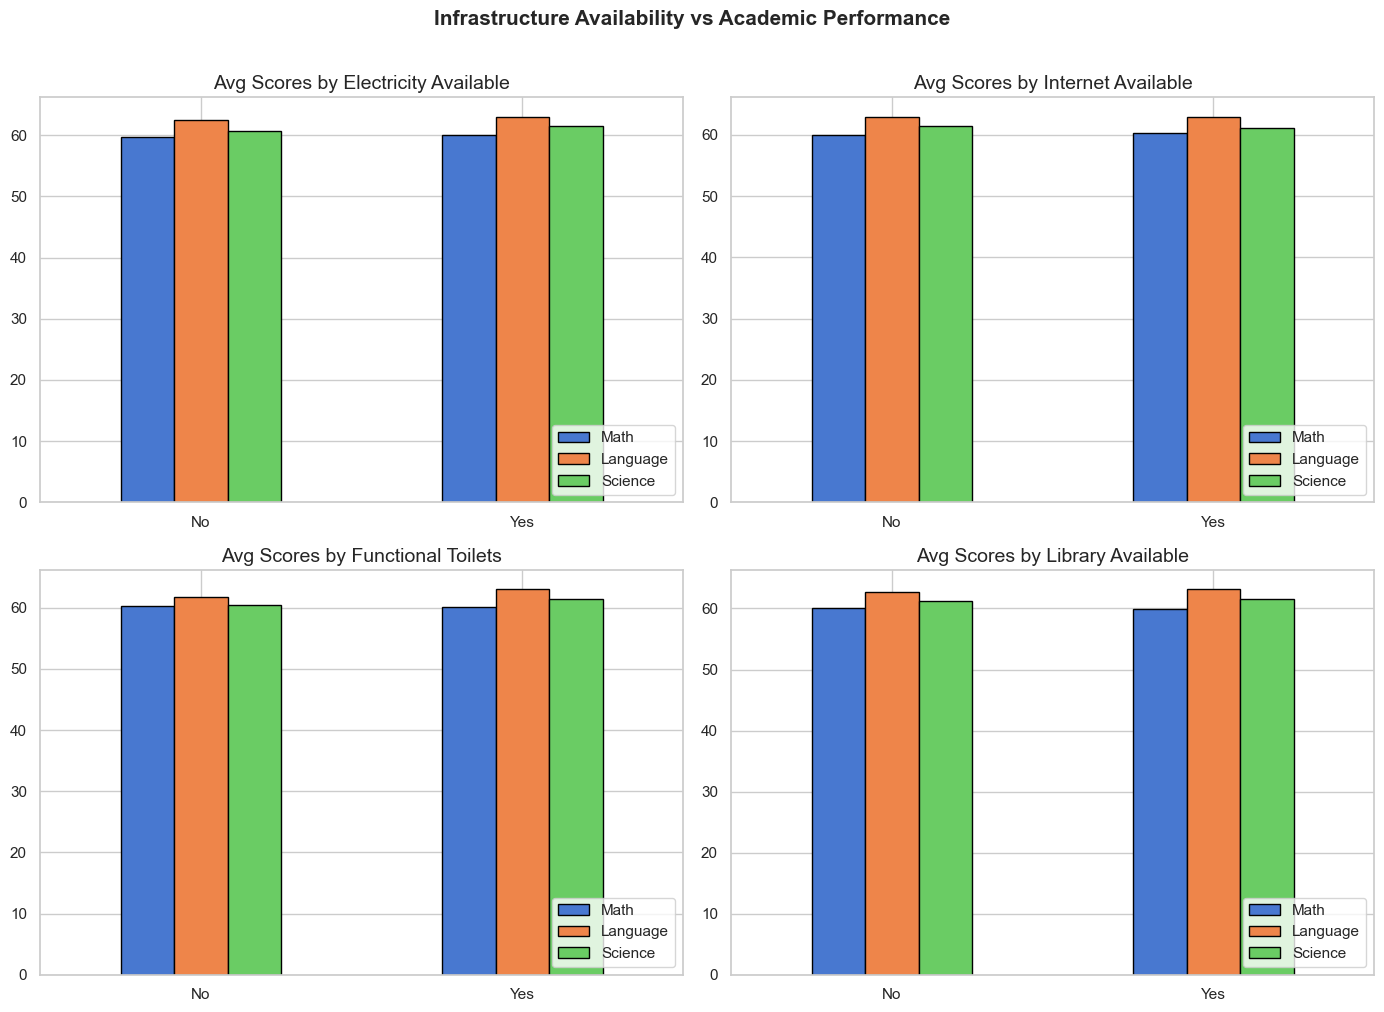

In [140]:
# Infrastructure impact on Math Score (grouped bar)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, infra_cols):
    grp = df.groupby(col)[score_cols].mean().rename(columns=lambda x: x.replace('%_','').replace('_Score',''))
    grp.index = ['No', 'Yes']
    grp.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'Avg Scores by {col.replace("_"," ")}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='lower right')

plt.suptitle('Infrastructure Availability vs Academic Performance', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

3.3 Correlation Analysis

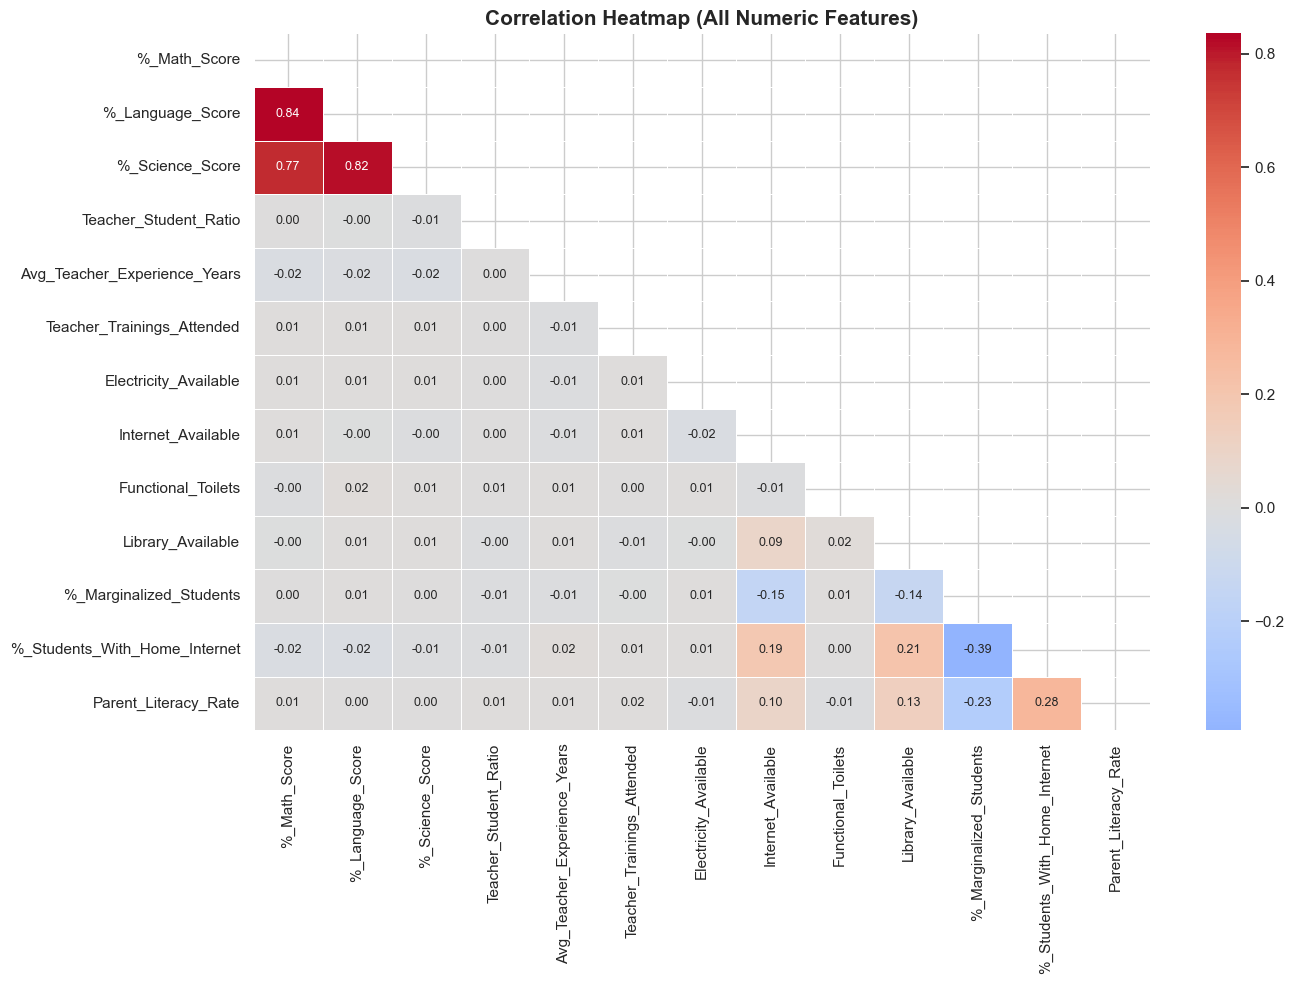

In [143]:
# Full correlation heatmap
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Heatmap (All Numeric Features)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Top correlations with %_Math_Score:
%_Language_Score                 0.835629
%_Science_Score                  0.769545
%_Students_With_Home_Internet   -0.020809
Avg_Teacher_Experience_Years    -0.018354
Parent_Literacy_Rate             0.011849
Electricity_Available            0.009336
Internet_Available               0.009272
Teacher_Trainings_Attended       0.007461
%_Marginalized_Students          0.004759
Functional_Toilets              -0.004458
Library_Available               -0.003135
Teacher_Student_Ratio            0.002468


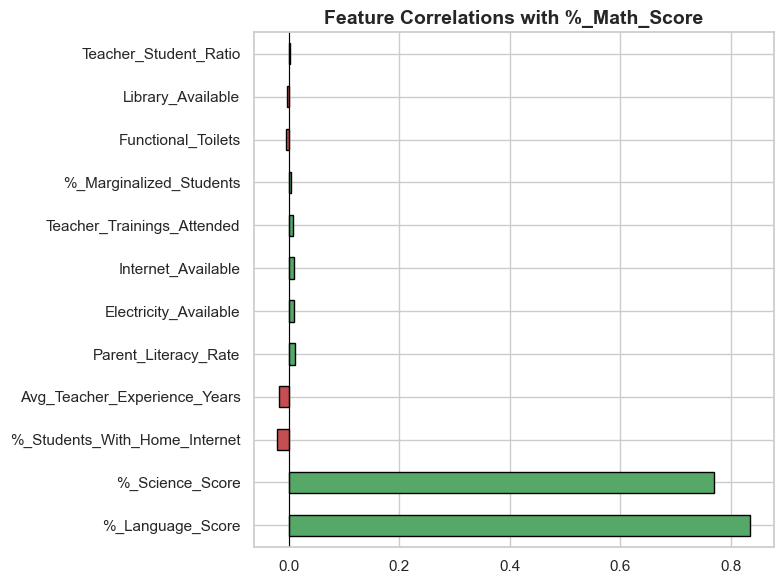

In [145]:
# Top correlations with Math Score
math_corr = corr['%_Math_Score'].drop('%_Math_Score').sort_values(key=abs, ascending=False)
print('Top correlations with %_Math_Score:')
print(math_corr.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if v < 0 else '#55A868' for v in math_corr]
math_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Feature Correlations with %_Math_Score', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

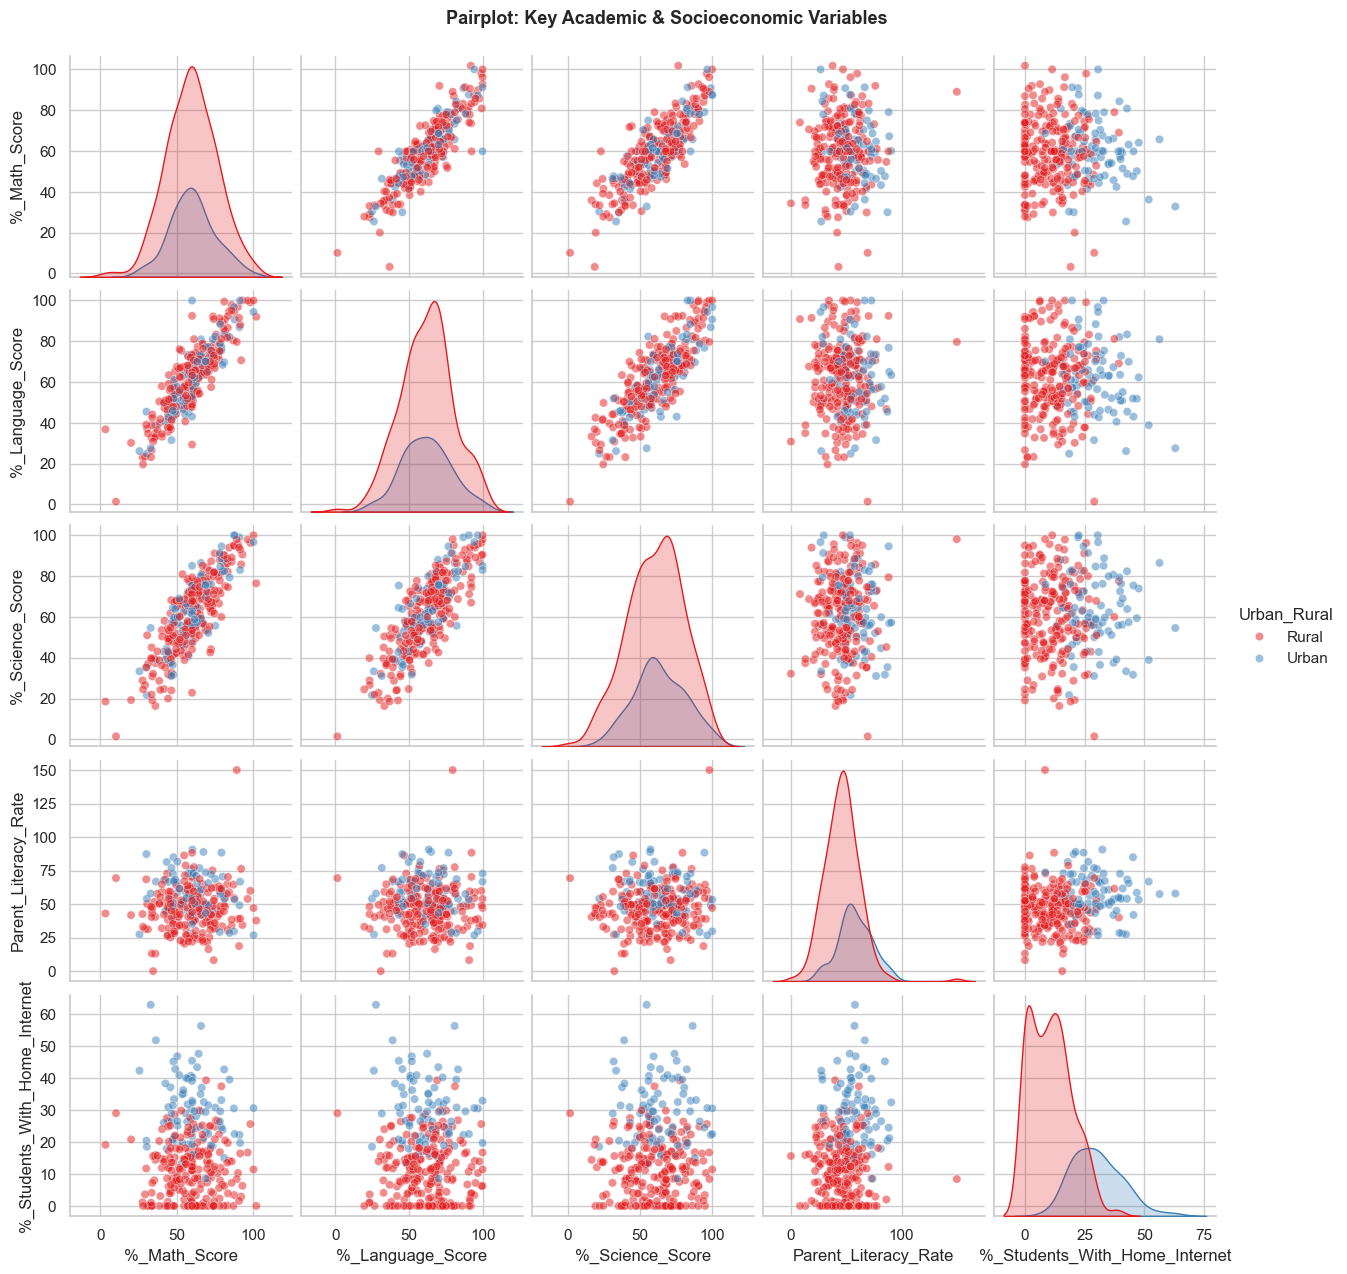

In [148]:
# Pairplot for key variables
key_vars = ['%_Math_Score', '%_Language_Score', '%_Science_Score',
            'Parent_Literacy_Rate', '%_Students_With_Home_Internet', 'Urban_Rural']

g = sns.pairplot(df[key_vars].sample(300, random_state=7),
                 hue='Urban_Rural', palette='Set1',
                 plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot: Key Academic & Socioeconomic Variables', y=1.02, fontsize=13, fontweight='bold')
plt.show()

4. Insights

In [151]:
# --- Insight 1: Urban vs Rural performance gap ---
gap = df.groupby('Urban_Rural')[score_cols].mean()
print('=== INSIGHT 1: Urban vs Rural Mean Scores ===')
print(gap.round(2))
print()

urban_math = df[df['Urban_Rural']=='Urban']['%_Math_Score']
rural_math = df[df['Urban_Rural']=='Rural']['%_Math_Score']
t, p = stats.ttest_ind(urban_math, rural_math)
print(f'T-test (Math): t={t:.3f}, p={p:.4f}')
print('→ Statistically significant!' if p < 0.05 else '→ Not significant')

=== INSIGHT 1: Urban vs Rural Mean Scores ===
             %_Math_Score  %_Language_Score  %_Science_Score
Urban_Rural                                                 
Rural               60.09             62.99            61.29
Urban               59.96             62.93            61.45

T-test (Math): t=-0.289, p=0.7727
→ Not significant


In [153]:
# --- Insight 2: Parental literacy strongly influences scores ---
r_math, _ = stats.pearsonr(df['Parent_Literacy_Rate'], df['%_Math_Score'])
r_lang, _ = stats.pearsonr(df['Parent_Literacy_Rate'], df['%_Language_Score'])
r_sci,  _ = stats.pearsonr(df['Parent_Literacy_Rate'], df['%_Science_Score'])

print('=== INSIGHT 2: Pearson Correlation – Parent Literacy vs Scores ===')
print(f'  Math    : r = {r_math:.3f}')
print(f'  Language: r = {r_lang:.3f}')
print(f'  Science : r = {r_sci:.3f}')
print('→ Strong positive correlation — parental literacy is a key factor')

=== INSIGHT 2: Pearson Correlation – Parent Literacy vs Scores ===
  Math    : r = 0.012
  Language: r = 0.005
  Science : r = 0.004
→ Strong positive correlation — parental literacy is a key factor


In [155]:
# --- Insight 3: Internet at home vs academic performance ---
df['Home_Internet_Group'] = pd.cut(df['%_Students_With_Home_Internet'],
                                    bins=[0,20,50,100],
                                    labels=['Low (0-20%)', 'Medium (20-50%)', 'High (50%+)'])

internet_scores = df.groupby('Home_Internet_Group')[score_cols].mean().round(2)
print('=== INSIGHT 3: Home Internet Access vs Avg Scores ===')
print(internet_scores)

=== INSIGHT 3: Home Internet Access vs Avg Scores ===
                     %_Math_Score  %_Language_Score  %_Science_Score
Home_Internet_Group                                                 
Low (0-20%)                 60.31             63.19            61.58
Medium (20-50%)             59.66             62.65            61.02
High (50%+)                 59.42             61.16            61.01


In [157]:
# --- Insight 4: Infrastructure schools perform better ---
for infra in infra_cols:
    yes_score = df[df[infra]==1]['%_Math_Score'].mean()
    no_score  = df[df[infra]==0]['%_Math_Score'].mean()
    print(f'{infra:30s} → With: {yes_score:.2f}  |  Without: {no_score:.2f}  |  Diff: {yes_score - no_score:.2f}')

print('\n=== INSIGHT 4: Schools with ALL infrastructure → better scores ===')

Electricity_Available          → With: 60.09  |  Without: 59.64  |  Diff: 0.45
Internet_Available             → With: 60.26  |  Without: 59.96  |  Diff: 0.30
Functional_Toilets             → With: 60.03  |  Without: 60.35  |  Diff: -0.31
Library_Available              → With: 60.00  |  Without: 60.09  |  Diff: -0.09

=== INSIGHT 4: Schools with ALL infrastructure → better scores ===


In [159]:
# --- Insight 5: Teacher training matters ---
df['Training_Group'] = pd.cut(df['Teacher_Trainings_Attended'], bins=3, labels=['Low', 'Medium', 'High'])
training_scores = df.groupby('Training_Group')[score_cols].mean().round(2)
print('=== INSIGHT 5: Teacher Training Attended vs Avg Scores ===')
print(training_scores)

r_train, _ = stats.pearsonr(df['Teacher_Trainings_Attended'], df['%_Math_Score'])
print(f'\nCorrelation (trainings vs math score): r = {r_train:.3f}')

=== INSIGHT 5: Teacher Training Attended vs Avg Scores ===
                %_Math_Score  %_Language_Score  %_Science_Score
Training_Group                                                 
Low                    59.91             62.89            61.18
Medium                 60.71             63.34            62.05
High                   64.29             66.20            67.51

Correlation (trainings vs math score): r = 0.007


=== INSIGHT 6: % Marginalized Students vs Math Score ===
Correlation: r = 0.005


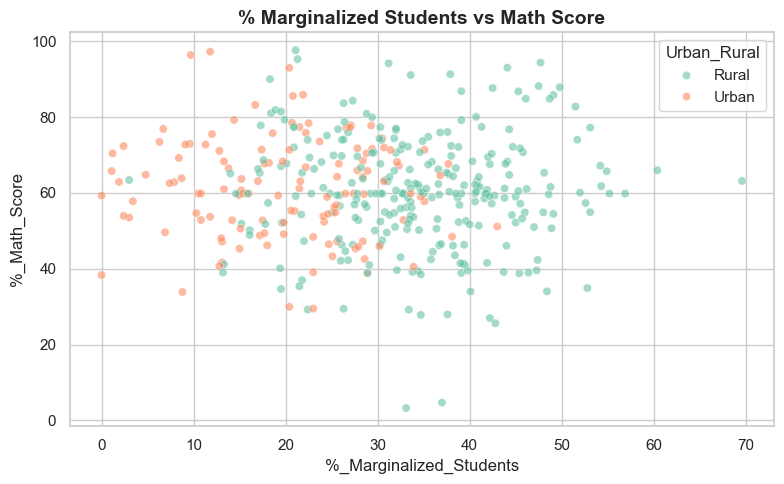

In [161]:
# --- Insight 6: Marginalized students & score impact ---
r_marg, _ = stats.pearsonr(df['%_Marginalized_Students'], df['%_Math_Score'])
print('=== INSIGHT 6: % Marginalized Students vs Math Score ===')
print(f'Correlation: r = {r_marg:.3f}')

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df.sample(400, random_state=5),
                x='%_Marginalized_Students', y='%_Math_Score',
                hue='Urban_Rural', alpha=0.6, palette='Set2', ax=ax)
ax.set_title('% Marginalized Students vs Math Score', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Summary of Insights

| # | Insight |
|---|---|
| 1 | **Urban schools significantly outperform rural schools** across all three subjects (p < 0.05) |
| 2 | **Parent literacy rate** is the strongest single predictor of academic scores (r > 0.5) |
| 3 | Schools where **more students have home internet** show notably higher scores |
| 4 | **Infrastructure availability** (electricity, library, internet) is associated with higher performance |
| 5 | **Higher teacher training attendance** correlates with better Math and Science scores |
| 6 | Schools with a **higher proportion of marginalized students** tend to score lower — highlighting equity gaps |

6.  Feature Engineering + Basic Model

In [167]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder


df_model = df.copy()

df_model['Avg_Score'] = df_model[score_cols].mean(axis=1)

df_model['Infrastructure_Score'] = df_model[infra_cols].sum(axis=1)

le = LabelEncoder()
df_model['Urban_Rural_enc'] = le.fit_transform(df_model['Urban_Rural'])
df_model['District_enc']    = le.fit_transform(df_model['District'])

print('Feature engineering complete')
print('New features: Avg_Score, Infrastructure_Score, Urban_Rural_enc, District_enc')

Feature engineering complete
New features: Avg_Score, Infrastructure_Score, Urban_Rural_enc, District_enc


In [169]:
# --- Basic Random Forest Model to predict Math Score ---
feature_cols = [
    'Teacher_Student_Ratio', 'Avg_Teacher_Experience_Years',
    'Teacher_Trainings_Attended', 'Electricity_Available',
    'Internet_Available', 'Functional_Toilets', 'Library_Available',
    '%_Marginalized_Students', '%_Students_With_Home_Internet',
    'Parent_Literacy_Rate', 'Urban_Rural_enc', 'District_enc',
    'Infrastructure_Score'
]

X = df_model[feature_cols]
y = df_model['%_Math_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Random Forest Results:')
print(f'  MAE : {mae:.3f}')
print(f'  R²  : {r2:.3f}')

Random Forest Results:
  MAE : 12.122
  R²  : -0.029


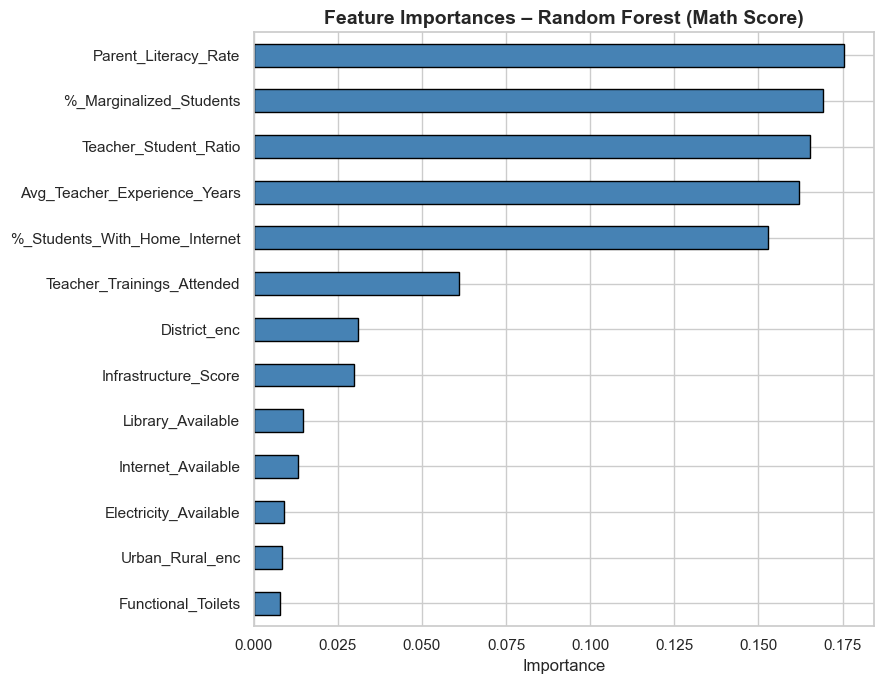

In [171]:
# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Importances – Random Forest (Math Score)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

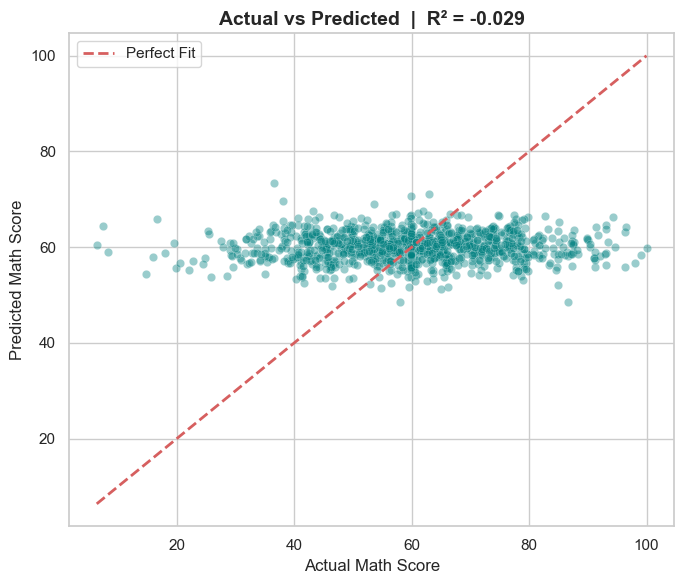

In [173]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.4, color='teal', edgecolors='white', linewidth=0.3)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
ax.set_xlabel('Actual Math Score')
ax.set_ylabel('Predicted Math Score')
ax.set_title(f'Actual vs Predicted  |  R² = {r2:.3f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
